Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [4]:
import gc
import time
from contextlib import contextmanager
import re

In [5]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [6]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
from sklearn import model_selection
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score,fbeta_score, make_scorer

In [47]:
import xgboost as xgb
import shap

## data

In [11]:
csv_path_output = '../data/output/'
file_name = 'homecredit_agg.csv'

df = pd.read_csv(f'{csv_path_output + file_name}', encoding='ISO-8859-1')

In [9]:
df.shape

(356251, 798)

In [10]:
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Explo

## Valeurs manquantes

In [ ]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [11]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [12]:
with timer ("Imputation des valeurs manquantes") :
     #  Statistiques sur les valeurs manquantes :
    missing_values = missing_values_table(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Séparation du jeu de données en jeu de  training/validation et jeu de test
    train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
    test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
    print(train_df.shape, test_df.shape)
    train_df["TARGET"].value_counts()/train_df.shape[0]
    
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
    print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.2536
Your selected dataframe has 798 columns.
There are 617 columns that have missing values.
(307507, 798) (48744, 798)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.2589
Taux de valeurs manquantes dans jeu de test avant imputation : 0.22
Imputation des valeurs manquantes - done in 3s


# Typage

In [15]:
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.dtypes

index                                 int64
SK_ID_CURR                            int64
TARGET                              float64
CODE_GENDER                           int64
FLAG_OWN_CAR                          int64
                                     ...   
CC_NAME_CONTRACT_STATUS_nan_MAX     float64
CC_NAME_CONTRACT_STATUS_nan_MEAN    float64
CC_NAME_CONTRACT_STATUS_nan_SUM     float64
CC_NAME_CONTRACT_STATUS_nan_VAR     float64
CC_COUNT                            float64
Length: 798, dtype: object

In [12]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())

# Analyse de la distribution des données
for column in df.columns:
    if df[column].dtype == 'int64':
        min_val, max_val = df[column].min(), df[column].max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            df[column] = df[column].astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            df[column] = df[column].astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            df[column] = df[column].astype(np.int32)
    elif df[column].dtype == 'float64':
        df[column] = df[column].astype(np.float32)

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())

Dtypes initiaux :
float64    622
int64      176
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None

Dtypes après conversion :
float32    622
int8       172
int32        2
int16        2
dtype: int64

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float32(622), int16(2), int32(2), int8(172)
memory usage: 907.8 MB
None


In [19]:
df['TARGET'].value_counts(dropna=False)

0.0    282682
NaN     48744
1.0     24825
Name: TARGET, dtype: int64

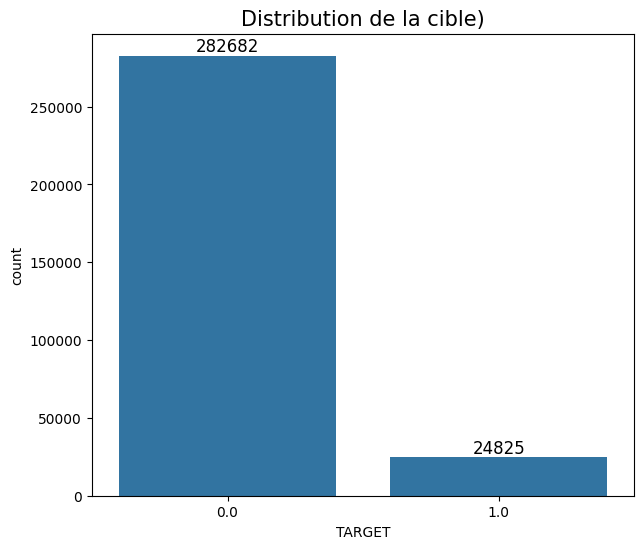

In [21]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=df)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [22]:
# Séparer les données en X_train et X_test
X_train = df[df['TARGET'].notna()]
X_test = df[df['TARGET'].isna()]

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (307507, 798)
Dimensions de X_test : (48744, 798)


In [37]:
X_train['TARGET'].value_counts(dropna=False)

0    282682
1     24825
Name: TARGET, dtype: int64

In [38]:
# Compter le nombre d'éléments ayant TARGET à 1
count_target_1 = df['TARGET'].value_counts()[1]

# Sélectionner aléatoirement un nombre similaire d'éléments ayant TARGET à 0
df_target_0 = df[df['TARGET'] == 0]
df_target_0_sampled = df_target_0.sample(n=count_target_1, random_state=42)

# Sélectionner tous les éléments ayant TARGET à 1
df_target_1 = df[df['TARGET'] == 1]

# Combiner les deux ensembles pour former le nouvel ensemble X_train
X_train = pd.concat([df_target_0_sampled, df_target_1])

# Afficher les dimensions du nouvel ensemble X_train
print("Dimensions de X_train :", X_train.shape)
print("Décompte des valeurs de TARGET dans X_train :")
print(X_train['TARGET'].value_counts(dropna=False))

Dimensions de X_train : (49650, 798)
Décompte des valeurs de TARGET dans X_train :
0.0    24825
1.0    24825
Name: TARGET, dtype: int64


In [41]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
10203744


In [43]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                               Feature  Missing Percentage
0                        REFUSED_RATE_DOWN_PAYMENT_MIN           84.080564
1                         REFUSED_AMT_DOWN_PAYMENT_MAX           84.080564
2                       REFUSED_RATE_DOWN_PAYMENT_MEAN           84.080564
3                         REFUSED_AMT_DOWN_PAYMENT_MIN           84.080564
4                        REFUSED_RATE_DOWN_PAYMENT_MAX           84.080564
5                        REFUSED_AMT_DOWN_PAYMENT_MEAN           84.080564
6                          REFUSED_APP_CREDIT_PERC_VAR           81.079557
7                              ACTIVE_AMT_ANNUITY_MEAN           79.401813
8                               ACTIVE_AMT_ANNUITY_MAX           79.401813
9                              CLOSED_AMT_ANNUITY_MEAN           79.033233
10                              CLOSED_AMT_ANNUITY_MAX           79.033233
11                          CC_AMT_PAYMENT_CURRENT_V

In [45]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = df.isna().mean() * 100

# Créer des bins pour les pourcentages de valeurs manquantes
bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']

# Classer les caractéristiques dans les bins
missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)

# Compter le nombre de variables par bin
bin_counts = missing_bins.value_counts().sort_index()

# Calculer le pourcentage de variables dans chaque bin par rapport au total
total_variables = len(missing_percentages)
bin_percentages = (bin_counts / total_variables) * 100

# Créer un DataFrame pour afficher les résultats
bin_summary = pd.DataFrame({
    'Number of Variables': bin_counts,
    'Percentage of Total': bin_percentages
})

# Afficher le nombre de variables par bin et leur pourcentage par rapport au total
print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
print(bin_summary)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                       184            23.057644
0-20%                    325            40.726817
20-40%                    44             5.513784
40-60%                    33             4.135338
60-100%                  212            26.566416


# Modélisations + feature importance

## XGBoost

### Model

### Feature Importance (SHAPE)

## LightGBM

### Model

### Feature Importance (SHAPE)

## Random Forest

### Model

### Feature Importance (most important features)

## Consolidation / Sélection Features

## Export